# Naive Bayes Classifier - Gaussian
<hr>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, confusion_matrix)

### Loading Data

In [2]:
heart_data = pd.read_csv('../heart_disease.csv')

### Statistical Summary

In [3]:
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
count,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,54.532202,0.685547,3.149414,131.478621,246.965108,0.165039,1.001953,149.638107,0.345703,1.090142,1.619141,0.681641,4.701172,0.923828,0.458984
std,9.273400,0.464525,0.971812,17.506230,52.561237,0.371397,0.993624,23.480260,0.475829,1.072306,0.620176,0.947402,1.941107,1.070377,0.498558
min,18.000000,0.000000,1.000000,84.869643,100.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.193472,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.555581,0.000000,0.152062,1.000000,0.000000,3.000000,0.000000,0.000000
50%,55.000000,1.000000,3.000000,130.012111,244.996816,0.000000,1.000000,151.524700,0.000000,0.854977,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.196437,1.000000,4.000000,142.412148,280.232245,0.000000,2.000000,165.642437,1.000000,1.630471,2.000000,1.000000,7.000000,2.000000,1.000000
max,78.795030,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,227.196592,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


### Feature Preprocessing

In [4]:
# Drop 'num' column and Separate features(X) and target(y)
X = heart_data.drop(columns=['target_binary', 'num'])
y = heart_data['target_binary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Shape of X:", X.shape)
print("Train size:", X_train_scaled.shape[0])
print("Test size:", X_test_scaled.shape[0])

Shape of X: (1024, 13)
Train size: 819
Test size: 205


### Training Naive Bayes Model

In [5]:
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[443.,376.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.54,0.46]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 13)","[[-0.2 ,-0.27,-0.4 ,...,-0.31,-0.45,-0.46], [ 0.24, 0.32, 0.47,..., 0.37, 0.53, 0.54]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 13)","[[1.2 ,1.15,0.93,...,0.93,0.41,0.65], [0.66,0.64,0.68,...,0.82,1.18,0.86]]"


### Predicting using the trained model

In [6]:
naive_bayes_predicted_y = naive_bayes_model.predict(X_test_scaled)
naive_bayes_probability_y = naive_bayes_model.predict_proba(X_test_scaled)[:,1]

print("Naive Bayes Classifier training done!")

Naive Bayes Classifier training done!


### Performance Metrics

In [7]:
naive_bayes_accuracy  = accuracy_score(y_test, naive_bayes_predicted_y)
naive_bayes_auc       = roc_auc_score(y_test, naive_bayes_probability_y)
naive_bayes_precision = precision_score(y_test, naive_bayes_predicted_y)
naive_bayes_recall    = recall_score(y_test, naive_bayes_predicted_y)
naive_bayes_f1        = f1_score(y_test, naive_bayes_predicted_y)
naive_bayes_mcc       = matthews_corrcoef(y_test, naive_bayes_predicted_y)

print("Naive Bayes Classifier Performance Metrics")
print(f"Accuracy  : {naive_bayes_accuracy:.4f}")
print(f"AUC       : {naive_bayes_auc:.4f}")
print(f"Precision : {naive_bayes_precision:.4f}")
print(f"Recall    : {naive_bayes_recall:.4f}")
print(f"F1 Score  : {naive_bayes_f1:.4f}")
print(f"MCC       : {naive_bayes_mcc:.4f}")

Naive Bayes Classifier Performance Metrics
Accuracy  : 0.8439
AUC       : 0.9131
Precision : 0.8298
Recall    : 0.8298
F1 Score  : 0.8298
MCC       : 0.6856


### Confusion Matrix

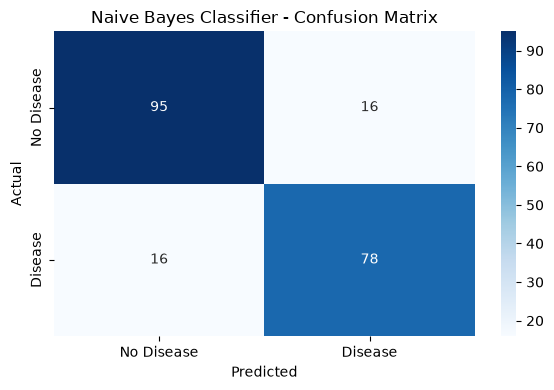

In [8]:
cm = confusion_matrix(y_test, naive_bayes_predicted_y)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Naive Bayes Classifier - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Saved Trained model pkl file

In [9]:
joblib.dump(naive_bayes_model, './pkl_files/naive_bayes.pkl')
print("naive_bayes.pkl' saved!")

naive_bayes.pkl' saved!
